In [1]:
# Install (if fresh env)
# !pip install -q torch torchvision matplotlib pillow numpy scipy
# !pip install -q git+https://github.com/facebookresearch/segment-anything.git
# !pip install -q open_clip_torch

import os
from pathlib import Path
import numpy as np
import torch
import torchvision
import torchvision.transforms as T
import torchvision.ops as ops
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image
import scipy.ndimage as ndi
import torch.nn.functional as F

from segment_anything import sam_model_registry, SamPredictor
import open_clip


/home/scs_deal_projects_notapebackup/user/shubhang/thesis/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
IMAGES_DIR = Path("/home/scs_deal_projects_notapebackup/user/shubhang/thesis/data/raw")
IMAGES_EXT = {".jpg", ".jpeg", ".png"}
OUT_DIR = Path("./baseline_sam_clip_out")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# SAM checkpoint (download beforehand)
SAM_VARIANT = "vit_h"   # "vit_b", "vit_l", "vit_h"
SAM_CKPT = Path("/home/scs_deal_projects_notapebackup/user/shubhang/thesis/third_party/checkpoints/sam_vit_h_4b8939.pth")

DEVICE = "cpu"
print("Device:", DEVICE)


Device: cpu


In [3]:
def load_image_rgb(p: Path) -> np.ndarray:
    return np.array(Image.open(p).convert("RGB"))

def show_overlay(img_rgb: np.ndarray, masks: list[np.ndarray], title=""):
    overlay = img_rgb.copy()
    for i, m in enumerate(masks):
        color = (np.array(plt.cm.tab20(i % 20)[:3]) * 255).astype(np.uint8)
        overlay[m] = (0.55*color + 0.45*overlay[m]).astype(np.uint8)
    plt.figure(figsize=(7,7)); plt.imshow(overlay); plt.axis("off"); plt.title(title); plt.show()

def save_mask_png(mask: np.ndarray, out_path: Path):
    Image.fromarray((mask.astype(np.uint8) * 255)).save(out_path)

def mask_iou(m1: np.ndarray, m2: np.ndarray) -> float:
    inter = np.logical_and(m1, m2).sum()
    uni   = np.logical_or(m1, m2).sum()
    return float(inter) / (float(uni) + 1e-9)

def nms_masks(masks: list[np.ndarray], iou_thr: float = 0.4) -> list[np.ndarray]:
    if not masks: return []
    areas = [m.sum() for m in masks]
    order = list(np.argsort(areas))[::-1]  # big→small
    kept = []
    for idx in order:
        m = masks[idx]
        if all(mask_iou(m, k) <= iou_thr for k in kept):
            kept.append(m)
    return kept


In [4]:
assert SAM_CKPT.exists(), f"Missing SAM weights at {SAM_CKPT}"
sam = sam_model_registry[SAM_VARIANT](checkpoint=str(SAM_CKPT))
sam.to(DEVICE).eval()
predictor = SamPredictor(sam)
print("SAM ready:", SAM_VARIANT)

# TorchVision FasterRCNN as RPN
rpn_model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights="DEFAULT").to(DEVICE).eval()
to_tensor = T.Compose([T.ToTensor()])


SAM ready: vit_h


In [5]:
@torch.no_grad()
def detect_boxes_rpn(img_rgb, score_thresh=0.6, nms_iou=0.5, topk=150):
    x = to_tensor(Image.fromarray(img_rgb)).to(DEVICE)
    out = rpn_model([x])[0]
    boxes, scores = out["boxes"], out["scores"]
    keep = scores >= score_thresh
    boxes, scores = boxes[keep], scores[keep]
    if boxes.numel() == 0: return []
    keep_idx = ops.nms(boxes, scores, nms_iou)[:topk]
    return boxes[keep_idx].cpu().numpy().astype(np.float32).tolist()

def sam_mask_from_box(img_rgb, box_xyxy):
    predictor.set_image(img_rgb)
    b = np.array(box_xyxy, dtype=np.float32)[None, :]
    masks, scores, _ = predictor.predict(box=b, multimask_output=True)
    m = masks[int(np.argmax(scores))].astype(bool)
    m = ndi.binary_closing(m, structure=np.ones((3,3), bool))
    m = ndi.binary_fill_holes(m)
    return m

def infer_instances(img_rgb,
                    score_thresh=0.6, nms_iou=0.5,
                    mask_nms_iou=0.4,
                    min_area_frac=0.005, max_area_frac=0.65):
    H, W = img_rgb.shape[:2]
    boxes = detect_boxes_rpn(img_rgb, score_thresh, nms_iou)
    cand_masks = []
    for b in boxes:
        m = sam_mask_from_box(img_rgb, b)
        area = m.sum()
        if area < min_area_frac*H*W or area > max_area_frac*H*W:
            continue
        cand_masks.append(m)
    return nms_masks(cand_masks, iou_thr=mask_nms_iou)


In [6]:
@torch.no_grad()
def detect_boxes_rpn(img_rgb, score_thresh=0.6, nms_iou=0.5, topk=150):
    x = to_tensor(Image.fromarray(img_rgb)).to(DEVICE)
    out = rpn_model([x])[0]
    boxes, scores = out["boxes"], out["scores"]
    keep = scores >= score_thresh
    boxes, scores = boxes[keep], scores[keep]
    if boxes.numel() == 0: return []
    keep_idx = ops.nms(boxes, scores, nms_iou)[:topk]
    return boxes[keep_idx].cpu().numpy().astype(np.float32).tolist()

def sam_mask_from_box(img_rgb, box_xyxy):
    predictor.set_image(img_rgb)
    b = np.array(box_xyxy, dtype=np.float32)[None, :]
    masks, scores, _ = predictor.predict(box=b, multimask_output=True)
    m = masks[int(np.argmax(scores))].astype(bool)
    m = ndi.binary_closing(m, structure=np.ones((3,3), bool))
    m = ndi.binary_fill_holes(m)
    return m

def infer_instances(img_rgb,
                    score_thresh=0.6, nms_iou=0.5,
                    mask_nms_iou=0.4,
                    min_area_frac=0.005, max_area_frac=0.65):
    H, W = img_rgb.shape[:2]
    boxes = detect_boxes_rpn(img_rgb, score_thresh, nms_iou)
    cand_masks = []
    for b in boxes:
        m = sam_mask_from_box(img_rgb, b)
        area = m.sum()
        if area < min_area_frac*H*W or area > max_area_frac*H*W:
            continue
        cand_masks.append(m)
    return nms_masks(cand_masks, iou_thr=mask_nms_iou)


In [10]:
!pip install git+https://github.com/openai/CLIP.git


  Cloning https://github.com/openai/CLIP.git to /home/scs_deal_learning/pip_packages/pip-req-build-hkzk8wqm
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /home/scs_deal_learning/pip_packages/pip-req-build-hkzk8wqm
  Resolved https://github.com/openai/CLIP.git to commit dcba3cb2e2827b402d2701e7e1c7d9fed8a20ef1
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369549 sha256=5d3dec5418fff64468ec5ec6f98b73515bf1808178ca698f174769fd71b6f21f
  Stored in directory: /home/scs_deal_learning/pip_packages/pip-ephem-wheel-cache-2ahf4cds/wheels/3f/7c/a4/9b490845988bf7a4db33674d52f709f088f64392063872eb9a
Successfully built clip


In [12]:
!pip install --upgrade torchvision


  Using cached nvidia_cuda_nvrtc_cu12-12.8.93-py3-none-manylinux2010_x86_64.manylinux_2_12_x86_64.whl.metadata (1.7 kB)
  Using cached nvidia_cuda_runtime_cu12-12.8.90-py3-none-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (1.7 kB)
  Using cached nvidia_cuda_cupti_cu12-12.8.90-py3-none-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (1.7 kB)
  Using cached nvidia_cudnn_cu12-9.10.2.21-py3-none-manylinux_2_27_x86_64.whl.metadata (1.8 kB)
  Using cached nvidia_cublas_cu12-12.8.4.1-py3-none-manylinux_2_27_x86_64.whl.metadata (1.7 kB)
  Using cached nvidia_cufft_cu12-11.3.3.83-py3-none-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (1.7 kB)
  Using cached nvidia_curand_cu12-10.3.9.90-py3-none-manylinux_2_27_x86_64.whl.metadata (1.7 kB)
  Using cached nvidia_cusolver_cu12-11.7.3.90-py3-none-manylinux_2_27_x86_64.whl.metadata (1.8 kB)
  Using cached nvidia_cusparse_cu12-12.5.8.93-py3-none-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (1.8 kB)
  Using cache

In [7]:
import torchvision.models as models
import torch.nn.functional as F

clip_model, clip_preprocess = models.clip_vit_b_32(pretrained=True)
clip_model = clip_model.to(DEVICE).eval()



AttributeError: module 'torchvision.models' has no attribute 'clip_vit_b_32'

In [8]:
rm -rf ~/.cache/huggingface


In [8]:
!pip install git+https://github.com/openai/CLIP.git


  Cloning https://github.com/openai/CLIP.git to /home/scs_deal_learning/pip_packages/pip-req-build-7xu4zp44
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /home/scs_deal_learning/pip_packages/pip-req-build-7xu4zp44
  Resolved https://github.com/openai/CLIP.git to commit dcba3cb2e2827b402d2701e7e1c7d9fed8a20ef1
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [9]:
import clip

clip_model, clip_preprocess = clip.load("ViT-B/32", device=DEVICE, jit=False)
clip_model.eval()


100%|███████████████████████████████████████| 338M/338M [00:04<00:00, 75.8MiB/s]


CLIP(
  (visual): VisionTransformer(
    (conv1): Conv2d(3, 768, kernel_size=(32, 32), stride=(32, 32), bias=False)
    (ln_pre): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
    (transformer): Transformer(
      (resblocks): Sequential(
        (0): ResidualAttentionBlock(
          (attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
          )
          (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (mlp): Sequential(
            (c_fc): Linear(in_features=768, out_features=3072, bias=True)
            (gelu): QuickGELU()
            (c_proj): Linear(in_features=3072, out_features=768, bias=True)
          )
          (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        )
        (1): ResidualAttentionBlock(
          (attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
          

In [10]:
coco_labels = ["person", "bicycle", "car", "bus", "truck", "dog", "cat", "bottle"]
templates = ["a photo of a {}", "a close-up photo of a {}", "a cropped photo of a {}"]

text_tokens = []
for label in coco_labels:
    phrases = [t.format(label) for t in templates]
    tokens = clip.tokenize(phrases).to(DEVICE)  # shape [num_templates, 77]
    text_tokens.append(tokens)


In [11]:
import torch.nn.functional as F

with torch.no_grad():
    text_embeds = []
    for toks in text_tokens:
        feats = clip_model.encode_text(toks)
        feats = F.normalize(feats, dim=-1)
        text_embeds.append(feats.mean(0))
    text_embeds = torch.stack(text_embeds)  # L x D


In [12]:
def crop_from_mask(img_rgb, mask, pad_frac=0.1):
    y, x = np.where(mask)
    y1, y2, x1, x2 = y.min(), y.max(), x.min(), x.max()
    h, w = img_rgb.shape[:2]
    pad_y, pad_x = int((y2-y1)*pad_frac), int((x2-x1)*pad_frac)
    y1, y2 = max(0, y1-pad_y), min(h, y2+pad_y)
    x1, x2 = max(0, x1-pad_x), min(w, x2+pad_x)
    return Image.fromarray(img_rgb[y1:y2, x1:x2])


In [13]:
@torch.no_grad()
def classify_crop(crop_img, score_thr=0.3, margin_thr=0.05):
    x = clip_preprocess(crop_img).unsqueeze(0).to(DEVICE)
    img_feat = clip_model.encode_image(x)
    img_feat = F.normalize(img_feat, dim=-1)
    sims = (img_feat @ text_embeds.T).squeeze(0)   # (L,)
    scores = sims.cpu().numpy()
    top_idx = int(scores.argmax())
    top_score = scores[top_idx]
    sorted_scores = sorted(scores, reverse=True)
    margin = sorted_scores[0] - sorted_scores[1] if len(sorted_scores) > 1 else 1.0
    if top_score >= score_thr and margin >= margin_thr:
        return coco_labels[top_idx], float(top_score), float(margin)
    else:
        return "unknown", float(top_score), float(margin)


sam_input_example.jpg: 1 objects


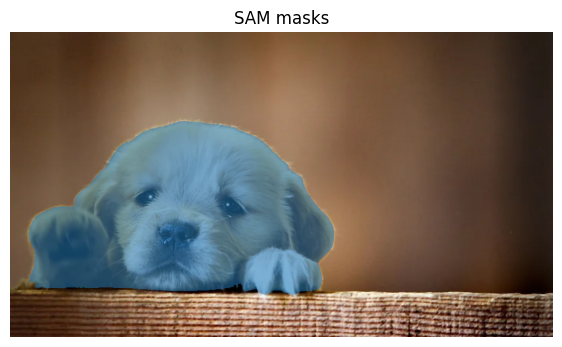

Instance 0: unknown (score=0.27, margin=0.06)


In [14]:
imgs = [p for p in IMAGES_DIR.iterdir() if p.suffix.lower() in IMAGES_EXT]
assert imgs, "No images found!"
img_path = imgs[0]
img_rgb = load_image_rgb(img_path)

instances = infer_instances(img_rgb)
print(f"{img_path.name}: {len(instances)} objects")

show_overlay(img_rgb, instances, title="SAM masks")

save_dir = OUT_DIR / img_path.stem
save_dir.mkdir(parents=True, exist_ok=True)
Image.fromarray(img_rgb).save(save_dir / "image_rgb.png")

results = []
for i, m in enumerate(instances):
    crop = crop_from_mask(img_rgb, m, pad_frac=0.2)
    label, score, margin = classify_crop(crop)
    results.append({"mask_id": i, "label": label, "score": score, "margin": margin})
    print(f"Instance {i}: {label} (score={score:.2f}, margin={margin:.2f})")
    crop.save(save_dir / f"crop_{i:02d}.png")
    save_mask_png(m, save_dir / f"mask_{i:02d}.png")

pd.DataFrame(results).to_csv(save_dir / "predictions.csv", index=False)
